In [19]:
%pip install pandas torch transformers deepparse huggingface_hub matplotlib ipympl rdflib sentence_transformers
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [20]:
import torch
if torch.cuda.is_available():
    print("CUDA - available devices:")
    for i in range(torch.cuda.device_count()):
        print(f"  {i}: {torch.cuda.get_device_name(i)}")
    device = torch.device('cuda')
elif torch.accelerator.is_available(): # Support other hardware accelators
    device = torch.accelerator.current_accelerator()
else:
    print("WARNING: Running on CPU")
    device = torch.device('cpu')
print(f"Torch version: {torch.__version__}, Device: {device}")

CUDA - available devices:
  0: NVIDIA A100 80GB PCIe
  1: NVIDIA A100 80GB PCIe
Torch version: 2.10.0+cu128, Device: cuda


In [21]:
from huggingface_hub import notebook_login
notebook_login()

In [22]:
from collections import OrderedDict
import pandas as pd
import json

COLS_TO_PREDICT = [
    "HouseNumber",
    "StreetName",
    "City",
    "State",
    "Country"
]

csv_read_args = dict(keep_default_na=False, dtype=str, na_values=[""])

bzkopen_train = pd.read_csv("open_data/bzkopen_addresses_train.csv", **csv_read_args)
bzkopen_val = pd.read_csv("open_data/bzkopen_addresses_val.csv", **csv_read_args)
bzkopen_test = pd.read_csv("open_data/bzkopen_addresses_test.csv", **csv_read_args)
EXAMPLES = [
    ("Berlin, Alexanderplatz 1, 10178", 
     OrderedDict([("City" , "Berlin"), ("StreetName", "Alexanderplatz"), ("HouseNumber", "1")])),
    ("Braunschweig, Uferstr. 25", # From BZK open training set
     OrderedDict([("City", "Braunschweig"), ("StreetName", "Uferstr."), ("HouseNumber", "25")])),
    ("808 Westend Avenue, New York 25, N.Y.", # From BZK open training set
        OrderedDict([("StreetName", "Westend Avenue"), ("HouseNumber", "808"), 
        ("City", "New York"), ("State", "N.Y.")])),
]



In [23]:

from mllms import JsonDictPromptTemplate, JSONTuplesPromptTemplate


PROMPTS = [
    JsonDictPromptTemplate("Segment addresses into their components.\n"
    "Output only a JSON object with the following keys: " + ", ".join(COLS_TO_PREDICT) + ". "
    "Do not include fields that cannot be determined and do not try to guess their values. "
    "For example, if the address is simply \"Berlin\" then the field \"Country\" should be null. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n%(examples)s"
    "Now segment the following address:\n%(address)s"),

    JSONTuplesPromptTemplate("Annotate address components with the respective types. "
    "Consider the component types: " + ", ".join(COLS_TO_PREDICT + ["Other"]) + ". "
    "Not all addresses will contain all component types and you must not guess the missing ones. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Output only a JSON list of [component, type] tuples.\n%(examples)s"
    "Now annotate the following address:\n%(address)s"),
]



for i, prompt in enumerate(PROMPTS):
    print(f"Prompt {i}:")
    print(prompt.template)
    print()

Prompt 0:
Segment addresses into their components.
Output only a JSON object with the following keys: HouseNumber, StreetName, City, State, Country. Do not include fields that cannot be determined and do not try to guess their values. For example, if the address is simply "Berlin" then the field "Country" should be null. Addresses will most times be written in german, meaning country and city names may be in german and the addresses may include german terms such as:
 - "burg" or "stadt" for city
 - "straße" or its abbreviation "str." for street.
These terms may occur as a suffix to another word.
%(examples)sNow segment the following address:
%(address)s

Prompt 1:
Annotate address components with the respective types. Consider the component types: HouseNumber, StreetName, City, State, Country, Other. Not all addresses will contain all component types and you must not guess the missing ones. Addresses will most times be written in german, meaning country and city names may be in german 

In [24]:
from deepparse_parser import DeepParseParser
from libpostal_client import LibpostalClient
from token_classifiers import TokenClassifierAddressParser
from mllms import LlamaAddressParsingModel, FixedExamples, ZeroShot, SimilarExamples
from itertools import combinations
import time
from pathlib import Path
from utils import compare_preds

model_configs = [
    {
        "name" : "libpostal",
        "factory": LibpostalClient,
        "cleanup": lambda client: client.close(),
    },
    {
        "name" : "libpostal-expanded",
        "factory": LibpostalClient,
        "factory_kargs" : {"expand_before_parsing": True},
        "cleanup": lambda client: client.close(),
    },
    {
        "name" : "deepparse-bpemb",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "device": device}
    },
    {
        "name" : "deepparse-fasttext",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "device": device}
    },
    {
        "name" : "deepparse-bpemb-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "attention_mechanism": True, "device": device}
    },
    {
        "name" : "deepparse-fasttext-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "attention_mechanism": True, "device": device}
    },
    {
         "name" : "xlm-roberta-large-address-parser", # from https://arxiv.org/abs/2404.05632
         "factory": TokenClassifierAddressParser,
         "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device}
    },
    {
         "name" : "xlm-roberta-large-address-parser-word-avg",
         "factory": TokenClassifierAddressParser,
         "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device, "aggregation_strategy": "average"}
    },
    {
         "name" : "xlm-roberta-large-address-parser-word-max",
         "factory": TokenClassifierAddressParser,
         "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device, "aggregation_strategy": "max"}
    }
]

LLAMA_MODELS = [
    ("Llama-3.2-1B", "meta-llama/Llama-3.2-1B-Instruct"),
    ("Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"),
    ("Llama-3-8B", "meta-llama/Meta-Llama-3-8B-Instruct"),
]

example_strategies = [
    ("0shot", ZeroShot())
]

for nshots in [1, 2]:
    for example_indices in combinations(range(len(EXAMPLES)), nshots):
        example_strategies.append((
             f"fixed{nshots}shot-ex{''.join(str(i) for i in example_indices)}", 
             FixedExamples([EXAMPLES[i] for i in example_indices])
        ))

example_strategies.append(("fixed3shot", FixedExamples(EXAMPLES)))

fixed_n_shot_model_configs = []

for example_strategy_id, example_strategy in example_strategies:
    for model_id, model_name in LLAMA_MODELS:
        for prompt_id, prompt in enumerate(PROMPTS):
                config_name = f"{model_id}-prompt{prompt_id}-{example_strategy_id}"
                config_dict = {
                    "name": config_name,
                    "factory": LlamaAddressParsingModel,
                    "factory_kargs" : {
                        "model_name": model_name,
                        "prompt": prompt,
                        "example_strategy": example_strategy,
                        "device": device
                    }
                }
                if (model_id, model_name) in LLAMA_MODELS[:2]:
                    fixed_n_shot_model_configs.append(config_dict)
                if example_strategy_id == "fixed3shot":
                    model_configs.append(config_dict)

model_configs.append({
    "name": "Llama-3-8B-prompt1-similar5shot",
    "factory": LlamaAddressParsingModel,
    "factory_kargs" : {
        "model_name": "meta-llama/Meta-Llama-3-8B-Instruct",
        "prompt": PROMPTS[1],
        "example_strategy": {
            "factory" : SimilarExamples,
            "factory_kargs": dict(
                example_addresses=bzkopen_train["FullAddress"],
                example_labels=bzkopen_train,
                num_examples=5,
                labels_to_include=COLS_TO_PREDICT,
                device=device
            )
        },
        "device": device
    }
})

for config in model_configs:
    print(f"Model config: {repr(config)}")


Model config: {'name': 'libpostal', 'factory': <class 'libpostal_client.LibpostalClient'>, 'cleanup': <function <lambda> at 0x7f92ec235620>}
Model config: {'name': 'libpostal-expanded', 'factory': <class 'libpostal_client.LibpostalClient'>, 'factory_kargs': {'expand_before_parsing': True}, 'cleanup': <function <lambda> at 0x7f92ec235ee0>}
Model config: {'name': 'deepparse-bpemb', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'device': device(type='cuda')}}
Model config: {'name': 'deepparse-fasttext', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'fasttext', 'device': device(type='cuda')}}
Model config: {'name': 'deepparse-bpemb-attention', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'attention_mechanism': True, 'device': device(type='cuda')}}
Model config: {'name': 'deepparse-fasttext-attention', 'factory': <class 'deepparse_parser.DeepParsePars

In [25]:
import traceback

def eval(dataset, configs, cols_to_predict, pred_cache_path=None):
    if pred_cache_path is not None:
        pred_cache_path = Path(pred_cache_path)
    if pred_cache_path is None or not pred_cache_path.exists():
        cached_preds = {}
    else:
        print(f"Loading cached predictions...")
        with open(pred_cache_path, "r") as f:
            cached_preds = json.load(f)
    
    preds_per_config = []
    model_results = []

    for config in configs:
        config_name = config["name"]
        if config_name in cached_preds:
            print(f"Using cached predictions for model {config_name}... To avoid this delete or rename the file {pred_cache_path} or delete the entry for {config_name} inside it.")
            preds = cached_preds[config_name]["preds"]
            deltatime = cached_preds[config_name]["deltatime"]
        else:
            try:
                print(f"Loading model {config_name}...")
                pargs = config.get("factory_pargs", [])
                kargs = config.get("factory_kargs", {})
                model = config["factory"](*pargs, **kargs)
                print(f"Segmenting addresses...")
                start = time.monotonic()
                preds = model.parse_addresses(dataset["FullAddress"].tolist())
                deltatime = time.monotonic() - start
                if "cleanup" in config:
                    print("Cleaning up model resources...")
                    config["cleanup"](model)
                print("Parsing model responses...")
                if pred_cache_path is not None:
                    cached_preds[config_name] = {
                        "preds": preds,
                        "deltatime": deltatime
                    }
            except Exception as e:
                print(f"Error while processing model {config_name}: {e}")
                traceback.print_exc()
                model_results.append({
                    "error" : len(dataset),
                    "errorRate" : 1.0
                })
                continue
        preds_df = pd.DataFrame(preds)
        preds_per_config.append(preds_df)
        print("Computing metrics...")
        metrics = compare_preds(preds_df, dataset[cols_to_predict], target_columns=cols_to_predict)
        metrics["deltatime"] = deltatime
        metrics["rate"] = len(dataset) / metrics["deltatime"]
        metrics["error"] = preds_df["error"].notna().sum() if "error" in preds_df.columns else 0
        metrics["errorRate"] = metrics["error"] / len(dataset)
        preds_df["config_name"] = config_name
        preds_df["FullAddress"] = dataset["FullAddress"]

        model_results.append(metrics)
        print(f"Results for model {config_name}: {metrics}")

    if pred_cache_path is not None:
        with open(pred_cache_path, "w") as f:
            json.dump(cached_preds, f)

    preds_per_config_df = pd.concat(preds_per_config)
    default_cols = ["config_name", "FullAddress"] + cols_to_predict
    new_order = default_cols + [col for col in preds_per_config_df.columns if col not in default_cols]
    preds_per_config_df = preds_per_config_df[new_order]

    results_df = pd.DataFrame(model_results, index = [config["name"] for config in configs])
    return preds_per_config_df, results_df



preds_per_config, model_statistics = eval(bzkopen_val, model_configs, COLS_TO_PREDICT, pred_cache_path="cached_preds_val.json")

model_statistics[["accuracy", "precision", "recall", "f1", "average_similarity", "errorRate", "rate"]]

Loading cached predictions...
Loading model libpostal...
Attempting to start libpostal-server docker-compose service...
This may take a long time on first run since the docker image needs to be built.


Failed to start libpostal-server docker container (exit code 1):

Traceback (most recent call last):
  File "/usr/lib/python3/dist-packages/urllib3/connectionpool.py", line 700, in urlopen
    httplib_response = self._make_request(
  File "/usr/lib/python3/dist-packages/urllib3/connectionpool.py", line 395, in _make_request
    conn.request(method, url, **httplib_request_kw)
  File "/usr/lib/python3.10/http/client.py", line 1303, in request
    self._send_request(method, url, body, headers, encode_chunked)
  File "/usr/lib/python3.10/http/client.py", line 1349, in _send_request
    self.endheaders(body, encode_chunked=encode_chunked)
  File "/usr/lib/python3.10/http/client.py", line 1298, in endheaders
    self._send_output(message_body, encode_chunked=encode_chunked)
  File "/usr/lib/python3.10/http/client.py", line 1058, in _send_output
    self.send(msg)
  File "/usr/lib/python3.10/http/client.py", line 996, in send
    self.connect()
  File "/usr/lib/python3/dist-packages/docker/tr

Traceback (most recent call last):
  File "/tmp/ipykernel_2025844/3064071967.py", line 27, in eval
    model = config["factory"](*pargs, **kargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/rpatroni/bzk-post-processing/libpostal_client.py", line 29, in __init__
    raise ConnectionError(f"Could not connect to libpostal server at {self.url}, and failed to start docker container.")
ConnectionError: Could not connect to libpostal server at http://localhost:7272, and failed to start docker container.
Traceback (most recent call last):
  File "/tmp/ipykernel_2025844/3064071967.py", line 27, in eval
    model = config["factory"](*pargs, **kargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/rpatroni/bzk-post-processing/libpostal_client.py", line 29, in __init__
    raise ConnectionError(f"Could not connect to libpostal server at {self.url}, and failed to start docker container.")
ConnectionError: Could not connect to libpostal server at http://localhost:7272, 

Results for model deepparse-bpemb: OrderedDict({'accuracy': 0.4328947368421053, 'precision': 0.2727272727272727, 'recall': 0.23684210526315788, 'f1': 0.2535211267605634, 'accuracy_with_tol_1': 0.4368421052631579, 'accuracy_with_tol_2': 0.45394736842105265, 'accuracy_with_tol_3': 0.4697368421052632, 'accuracy_with_tol_4': 0.4855263157894737, 'average_levenshtein': 3.488157894736842, 'average_similarity': 0.4951690760871127, 'average_levenshtein_match': 5.728070175438597, 'average_similarity_match': 0.8252817934785212, 'no_match_rate': 0.4, 'deltatime': 0.29123351722955704, 'rate': 521.91794902573, 'error': 0, 'errorRate': 0.0})
Using cached predictions for model deepparse-fasttext... To avoid this delete or rename the file cached_preds_val.json or delete the entry for deepparse-fasttext inside it.
Computing metrics...
Results for model deepparse-fasttext: OrderedDict({'accuracy': 0.475, 'precision': 0.33941605839416056, 'recall': 0.3059210526315789, 'f1': 0.3217993079584775, 'accuracy_w

,accuracy,precision,recall,f1,average_similarity,errorRate,rate
libpostal,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
libpostal-expanded,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
deepparse-bpemb,0.432895,0.272727,0.236842,0.253521,0.495169,0.000000,521.917949
deepparse-fasttext,0.475000,0.339416,0.305921,0.321799,0.537354,0.000000,5048.466303
deepparse-bpemb-attention,0.339474,0.103896,0.078947,0.089720,0.373814,0.000000,1193.280173
deepparse-fasttext-attention,0.311842,0.150327,0.151316,0.150820,0.347338,0.000000,2941.531074
xlm-roberta-large-address-parser,0.806579,0.606667,0.598684,0.602649,0.844694,0.000000,518.757643
xlm-roberta-large-address-parser-word-avg,0.819737,0.641638,0.618421,0.629816,0.852799,0.000000,516.071714
xlm-roberta-large-address-parser-word-max,0.815789,0.642361,0.608553,0.625000,0.847758,0.000000,560.469079
Llama-3.2-1B-prompt0-fixed3shot,0.525000,0.370526,0.578947,0.451861,0.553028,0.026316,8.363700


In [26]:
preds_per_config

,config_name,FullAddress,HouseNumber,StreetName,City,State,Country,Unit,PostalCode,OOV,...,StreetNameSuffix2,Direction,Postal,StreetNumber,CityName,StateName,CountryName,HouseNumber III,PlaceName,StreetType
0,deepparse-bpemb,"Regensburg, Königstr. 2/I",NaN,regensburg,königstr.,NaN,2/i,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,deepparse-bpemb,Dortmund,NaN,NaN,dortmund,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,deepparse-bpemb,"Nürnberg, Nibelungenstrasse 8",8,nürnberg nibelungenstrasse,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,deepparse-bpemb,Jöhlingen/Krs.Durlach/Baden.,NaN,NaN,jöhlingen/krs.durlach/baden.,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,deepparse-bpemb,"8 Burlington Road, Manchester 20/England.",8,burlington road,manchester 20/england.,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,Llama-3-8B-prompt1-similar5shot,2114-79 St. Jackson Heights. N.Y. USA,2114-79,NaN,Jackson Heights,N.Y.,USA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,Llama-3-8B-prompt1-similar5shot,Losone CSR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,Llama-3-8B-prompt1-similar5shot,"1544, Union St., Brooklyn, 13 N.Y.",1544,Union St.,Brooklyn,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,Llama-3-8B-prompt1-similar5shot,Rum.,NaN,NaN,NaN,NaN,Rum.,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
preds_per_nshots, model_statistics_nshots = eval(bzkopen_val, fixed_n_shot_model_configs, COLS_TO_PREDICT, pred_cache_path="cached_nshot_preds_val.json")
model_statistics_nshots[["accuracy", "precision", "recall", "f1", "errorRate", "rate"]]

Loading cached predictions...
Using cached predictions for model Llama-3.2-1B-prompt0-0shot... To avoid this delete or rename the file cached_nshot_preds_val.json or delete the entry for Llama-3.2-1B-prompt0-0shot inside it.
Computing metrics...
Results for model Llama-3.2-1B-prompt0-0shot: OrderedDict({'accuracy': 0.5447368421052632, 'precision': 0.33668341708542715, 'recall': 0.4407894736842105, 'f1': 0.3817663817663817, 'accuracy_with_tol_1': 0.5473684210526316, 'accuracy_with_tol_2': 0.5657894736842105, 'accuracy_with_tol_3': 0.5894736842105263, 'accuracy_with_tol_4': 0.6289473684210526, 'average_levenshtein': 3.3526315789473684, 'average_similarity': 0.5707445674924253, 'average_levenshtein_match': 5.375527426160337, 'average_similarity_match': 0.9151178719287831, 'no_match_rate': 0.37631578947368416, 'deltatime': 10.380314499139786, 'rate': 14.64310161436787, 'error': 1, 'errorRate': 0.006578947368421052})
Using cached predictions for model Llama-3.2-1B-prompt1-0shot... To avoid 

,accuracy,precision,recall,f1,errorRate,rate
Llama-3.2-1B-prompt0-0shot,0.544737,0.336683,0.440789,0.381766,0.006579,14.643102
Llama-3.2-1B-prompt1-0shot,0.535526,0.119565,0.036184,0.055556,0.243421,8.230923
Llama-3.2-3B-prompt0-0shot,0.747368,0.567568,0.621711,0.593407,0.065789,5.246221
Llama-3.2-3B-prompt1-0shot,0.613158,0.454545,0.065789,0.114943,0.631579,5.048454
Llama-3.2-1B-prompt0-fixed1shot-ex0,0.467105,0.427653,0.437500,0.432520,0.039474,10.125734
Llama-3.2-1B-prompt1-fixed1shot-ex0,0.728947,0.524823,0.486842,0.505119,0.105263,8.299805
Llama-3.2-3B-prompt0-fixed1shot-ex0,0.771053,0.617910,0.680921,0.647887,0.052632,4.858865
Llama-3.2-3B-prompt1-fixed1shot-ex0,0.793421,0.698413,0.578947,0.633094,0.032895,4.793028
Llama-3.2-1B-prompt0-fixed1shot-ex1,0.456579,0.406250,0.427632,0.416667,0.039474,10.248284
Llama-3.2-1B-prompt1-fixed1shot-ex1,0.773684,0.605166,0.539474,0.570435,0.131579,8.355220


In [28]:
default_cols = ["config_name", "FullAddress"] + COLS_TO_PREDICT
preds_vs_trues = preds_per_config[default_cols].merge(
    bzkopen_val[default_cols[1:]], on="FullAddress", suffixes=("_pred", "_true"), how="left")
preds_vs_trues = preds_vs_trues[["config_name", "FullAddress"] + [new_col for col in COLS_TO_PREDICT for new_col in [f"{col}_pred", f"{col}_true"]]] # Order the columns for readability
preds_vs_trues

,config_name,FullAddress,HouseNumber_pred,HouseNumber_true,StreetName_pred,StreetName_true,City_pred,City_true,State_pred,State_true,Country_pred,Country_true
0,deepparse-bpemb,"Regensburg, Königstr. 2/I",NaN,2/I,regensburg,Königstr.,königstr.,Regensburg,NaN,NaN,2/i,NaN
1,deepparse-bpemb,Dortmund,NaN,NaN,NaN,NaN,dortmund,Dortmund,NaN,NaN,NaN,NaN
2,deepparse-bpemb,"Nürnberg, Nibelungenstrasse 8",8,8,nürnberg nibelungenstrasse,Nibelungenstrasse,NaN,Nürnberg,NaN,NaN,NaN,NaN
3,deepparse-bpemb,Jöhlingen/Krs.Durlach/Baden.,NaN,NaN,NaN,NaN,jöhlingen/krs.durlach/baden.,Jöhlingen,NaN,Baden,NaN,NaN
4,deepparse-bpemb,"8 Burlington Road, Manchester 20/England.",8,8,burlington road,Burlington Road,manchester 20/england.,Manchester,NaN,NaN,NaN,England
...,...,...,...,...,...,...,...,...,...,...,...,...
2291,Llama-3-8B-prompt1-similar5shot,2114-79 St. Jackson Heights. N.Y. USA,2114-79,2114,NaN,79 St.,Jackson Heights,N.Y.,N.Y.,NaN,USA,USA
2292,Llama-3-8B-prompt1-similar5shot,Losone CSR,NaN,NaN,NaN,NaN,NaN,Losone,NaN,NaN,NaN,CSR
2293,Llama-3-8B-prompt1-similar5shot,"1544, Union St., Brooklyn, 13 N.Y.",1544,1544,Union St.,Union St.,Brooklyn,N.Y.,NaN,NaN,NaN,NaN
2294,Llama-3-8B-prompt1-similar5shot,Rum.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rum.,Rum.


In [29]:

metric = "f1"
model_statistics[[metric]]


,f1
libpostal,NaN
libpostal-expanded,NaN
deepparse-bpemb,0.253521
deepparse-fasttext,0.321799
deepparse-bpemb-attention,0.089720
deepparse-fasttext-attention,0.150820
xlm-roberta-large-address-parser,0.602649
xlm-roberta-large-address-parser-word-avg,0.629816
xlm-roberta-large-address-parser-word-max,0.625000
Llama-3.2-1B-prompt0-fixed3shot,0.451861


In [30]:
def get_n_shots(config_name):
    parts = config_name.split("-")
    example_indices = None
    for i, part in enumerate(parts):
        if part.endswith("shot"):
            nshots = int("".join(c for c in part if c.isdigit()))
            if nshots == 0:
                example_indices = []
            elif nshots == len(EXAMPLES):
                example_indices = list(range(len(EXAMPLES)))
            elif  len(parts) > i+1 and parts[i+1].startswith("ex"):
                example_indices = [int(c) for c in parts[i+1][2:]] # Remove "ex" prefix
            return nshots, example_indices, "-".join(parts[:i])
    return None, example_indices, None



metric_per_shot = pd.DataFrame(columns=pd.MultiIndex.from_tuples(
    [(get_n_shots(config["name"])[2], config["name"]) for config in fixed_n_shot_model_configs],
    names=["config_prefix", "config_name"]
))

example_config_tuples = []
for i in range(len(EXAMPLES)):
    for config in fixed_n_shot_model_configs:
        config_name = config["name"]
        n_shots, example_indices, config_prefix = get_n_shots(config_name)
        if n_shots is not None and example_indices is not None and i in example_indices:
            example_config_tuples.append((i, config_name))
metric_per_example_per_shot = pd.DataFrame(columns=pd.MultiIndex.from_tuples(example_config_tuples, names=["example_index", "config_name"]))



for config in fixed_n_shot_model_configs:
    config_name = config["name"]
    n_shots, example_indices, config_prefix = get_n_shots(config_name)
    if n_shots is not None:
        metric_per_shot.at[n_shots, (config_prefix, config_name)] = model_statistics_nshots.at[config_name, metric]
        for example_index in example_indices:
            metric_per_example_per_shot.at[n_shots, (example_index, config_name)] = model_statistics_nshots.at[config_name, metric]
metric_per_shot = metric_per_shot.stack(level=1).groupby(level=0).mean()
metric_per_shot.index.name = None
metric_per_shot["mean"] = metric_per_shot.mean(axis=1)

metric_per_example_per_shot = metric_per_example_per_shot.stack(level=1).groupby(level=0).mean()
metric_per_example_per_shot.loc[0] = metric_per_shot.at[0, "mean"]
metric_per_example_per_shot.sort_index(inplace=True)
metric_per_example_per_shot.columns.name = "example"
metric_per_example_per_shot.columns = [EXAMPLES[i][0][:10] + "..." for i in metric_per_example_per_shot.columns]


<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

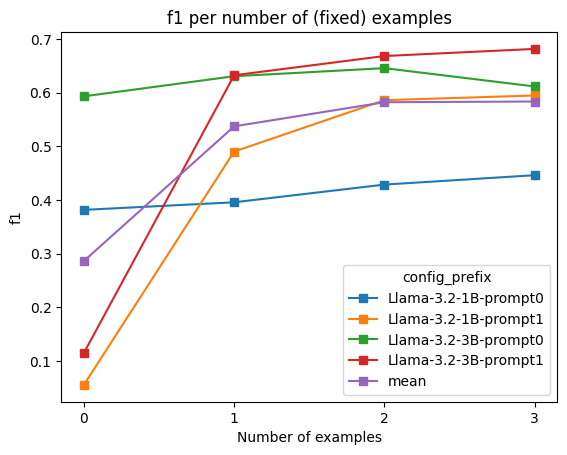

In [31]:

metric_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)

<Axes: title={'center': 'f1 for each example'}, xlabel='Number of examples', ylabel='f1'>

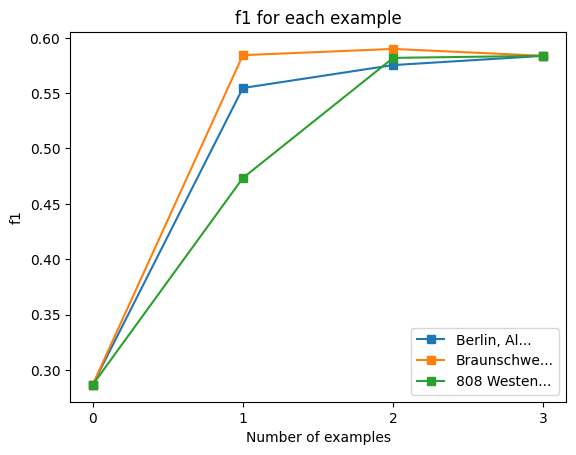

In [32]:
metric_per_example_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} for each example"
)

In [33]:
metric_per_column = pd.DataFrame(index=model_statistics.index, columns=COLS_TO_PREDICT)
for col in COLS_TO_PREDICT:
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        if len(preds) == 0:
            print(f"No predictions found for config {config} and column {col}, skipping.")
            continue
        if col in preds.columns:
            value = compare_preds(preds, bzkopen_val, target_columns=[col])[metric]
            metric_per_column.at[config, col] = value
        else:
            metric_per_column.at[config, col] = pd.NA
print(f"Per-column {metric} scores:")
metric_per_column

No predictions found for config libpostal and column HouseNumber, skipping.
No predictions found for config libpostal-expanded and column HouseNumber, skipping.
No predictions found for config libpostal and column StreetName, skipping.
No predictions found for config libpostal-expanded and column StreetName, skipping.
No predictions found for config libpostal and column City, skipping.
No predictions found for config libpostal-expanded and column City, skipping.
No predictions found for config libpostal and column State, skipping.
No predictions found for config libpostal-expanded and column State, skipping.
No predictions found for config libpostal and column Country, skipping.
No predictions found for config libpostal-expanded and column Country, skipping.
Per-column f1 scores:


,HouseNumber,StreetName,City,State,Country
libpostal,NaN,NaN,NaN,NaN,NaN
libpostal-expanded,NaN,NaN,NaN,NaN,NaN
deepparse-bpemb,0.64,0.027397,0.257813,0.0,0.169492
deepparse-fasttext,0.568807,0.075758,0.363636,0.0,0.272727
deepparse-bpemb-attention,0.231884,0.048387,0.009901,0.0,0.180451
deepparse-fasttext-attention,0.423529,0.045455,0.090498,0.0,0.231405
xlm-roberta-large-address-parser,0.803419,0.677686,0.462687,0.117647,0.765432
xlm-roberta-large-address-parser-word-avg,0.803419,0.722689,0.50566,0.117647,0.759494
xlm-roberta-large-address-parser-word-max,0.803419,0.728814,0.498084,0.117647,0.734177
Llama-3.2-1B-prompt0-fixed3shot,0.389744,0.35122,0.708029,0.105263,0.083333


<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

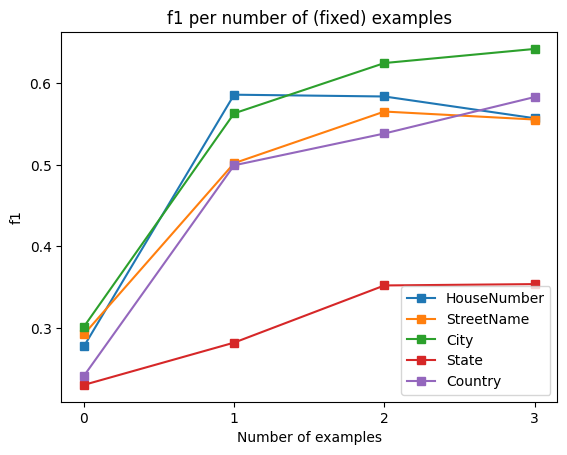

In [34]:
metric_per_column_per_shot = pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics_nshots.index, metric_per_shot.index]),
    columns=COLS_TO_PREDICT
)
for col in COLS_TO_PREDICT:
    for config in model_statistics_nshots.index:
        preds = preds_per_nshots[preds_per_nshots["config_name"] == config]
        if len(preds) == 0:
            print(f"No predictions found for config {config} and column {col}, skipping.")
            continue
        if col in preds.columns:
            value = compare_preds(preds, bzkopen_val, target_columns=[col])[metric]
            n_shots, example_indices, model_name = get_n_shots(config)
            if n_shots is not None:
                metric_per_column_per_shot.at[(config, n_shots), col] = value
        else:
            metric_per_column_per_shot.at[(config, 0), col] = pd.NA

metric_per_column_per_shot = metric_per_column_per_shot.groupby(level=1).mean()
metric_per_column_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)

In [35]:
bzk_fields = bzkopen_val["field"].unique()
print(f"bzk_fields: {bzk_fields}")
metric_per_bzk_field = pd.DataFrame(index=model_statistics.index, columns=bzk_fields)

for field in bzk_fields:
    mask = bzkopen_val["field"] == field
    subset = bzkopen_val[mask]
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        if len(preds) == 0:
            print(f"No predictions found for config {config} and column {col}, skipping.")
            continue
        value = compare_preds(preds[mask], subset, target_columns=COLS_TO_PREDICT)[metric]
        metric_per_bzk_field.at[config, field] = value
print(f"Per-BZK-field {metric} scores:")
metric_per_bzk_field

bzk_fields: <StringArray>
['ApplicantCurrentAddress',        'VictimBirthPlace',
    'VictimCurrentAddress',     'ApplicantBirthPlace',
        'VictimDeathPlace']
Length: 5, dtype: str
No predictions found for config libpostal and column Country, skipping.
No predictions found for config libpostal-expanded and column Country, skipping.
No predictions found for config libpostal and column Country, skipping.
No predictions found for config libpostal-expanded and column Country, skipping.
No predictions found for config libpostal and column Country, skipping.
No predictions found for config libpostal-expanded and column Country, skipping.
No predictions found for config libpostal and column Country, skipping.
No predictions found for config libpostal-expanded and column Country, skipping.
No predictions found for config libpostal and column Country, skipping.
No predictions found for config libpostal-expanded and column Country, skipping.
Per-BZK-field f1 scores:


,ApplicantCurrentAddress,VictimBirthPlace,VictimCurrentAddress,ApplicantBirthPlace,VictimDeathPlace
libpostal,NaN,NaN,NaN,NaN,NaN
libpostal-expanded,NaN,NaN,NaN,NaN,NaN
deepparse-bpemb,0.205128,0.375,0.25,0.30303,0.363636
deepparse-fasttext,0.241993,0.595745,0.294118,0.397059,0.5
deepparse-bpemb-attention,0.060606,0.064516,0.165138,0.108696,0.0
deepparse-fasttext-attention,0.130719,0.166667,0.22807,0.137405,0.0
xlm-roberta-large-address-parser,0.588235,0.545455,0.618182,0.621212,0.833333
xlm-roberta-large-address-parser-word-avg,0.594059,0.604651,0.66055,0.671756,0.909091
xlm-roberta-large-address-parser-word-max,0.594059,0.571429,0.666667,0.65625,0.909091
Llama-3.2-1B-prompt0-fixed3shot,0.57329,0.336842,0.578512,0.280851,0.380952


<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

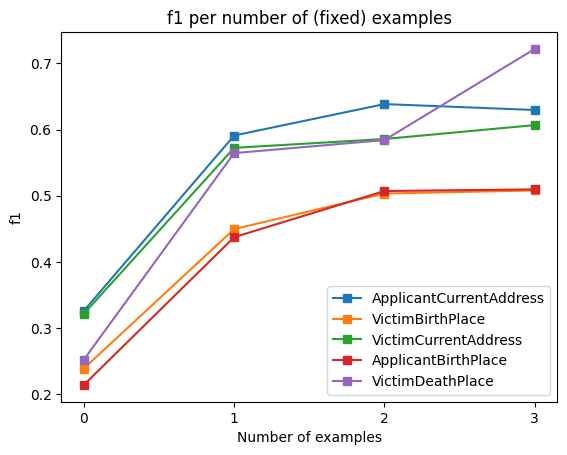

In [36]:
metric_per_bzk_field_per_shot =  pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics_nshots.index, metric_per_shot.index]),
    columns=bzk_fields
)

for field in bzk_fields:
    mask = bzkopen_val["field"] == field
    subset = bzkopen_val[mask]
    for config in model_statistics_nshots.index:
        preds = preds_per_nshots[preds_per_nshots["config_name"] == config]
        if len(preds) == 0:
            print(f"No predictions found for config {config} and column {col}, skipping.")
            continue
        value = compare_preds(preds[mask], subset, target_columns=COLS_TO_PREDICT)[metric]
        n_shots, example_indices, model_name = get_n_shots(config)
        if n_shots is not None:
            metric_per_bzk_field_per_shot.at[(config, n_shots), field] = value

metric_per_bzk_field_per_shot = metric_per_bzk_field_per_shot.groupby(level=1).mean()
metric_per_bzk_field_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)